# **Project - 3 Data Analytics**

**To complete this project, tasks need to do:**
- Customer Segmentation Based on Spend in Dollars, based on Swipes, segmentation example below. You can create more segment as per your wisdom.
  - Young Females
  - Mid age Females
  - Old Females
  - Young Males
  - Mid age Males
  - Old Males
- Calculate the spend in terms of Product, State and Payment method.
- Calculate the highest 5 spending in all above categories.
- Give your opinion on return category like customers returning the products belongs to which state, age group, condition, category of the product or is it related to discount.
- Create a profile of customers in terms of timing of their order.
- Which payment method is providing more discount for customers?
- Create a profile for high value items vs low value items and relate that wrt to their number of orders.
- Do you think if merchant provides more discount then can it will lead to increase in number of orders?mber of
orders?

#### **Loading the required libraries.......**

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [102]:
# Dataset
df_project = pd.read_excel(r"C:\Users\user\Desktop\Copy of Credit Banking - 3.xls", sheet_name = "Dataset")
df_project.head(100)

,Credit_card,Product_ID,P_CATEGORY,CONDTION,Brand,Price,Selling_price,Coupon_ID,Date,Time,GTIN,MPN,Merchant_name,M_ID,Payment Method,Transaction ID,Return_ind,Return_date
0,1093.0,198,KITCHEN & DINING,Refurbished,RGMIK,3643.75,3606.75,HW589,2014-01-28,04:04:46,3452394,624342544,Nine West,RM9837,Credit card,60593,1,2014-02-04
1,1093.0,198,KITCHEN & DINING,Refurbished,RGMIK,3643.75,3606.75,HW589,2014-01-28,04:04:46,3452394,624342544,Nine West,RM9837,Credit card,60593,0,NaT
2,1093.0,198,KITCHEN & DINING,Refurbished,RGMIK,3643.75,3606.75,HW589,2014-01-28,04:04:46,3452394,624342544,Nine West,RM9837,Credit card,60593,0,NaT
3,1093.0,198,KITCHEN & DINING,Refurbished,RGMIK,3643.75,3606.75,HW589,2014-01-28,04:04:46,3452394,624342544,Nine West,RM9837,Credit card,60593,0,NaT
4,1093.0,198,KITCHEN & DINING,Refurbished,RGMIK,3643.75,3606.75,HW589,2014-01-28,04:04:46,3452394,624342544,Nine West,RM9837,Credit card,60593,0,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1177.0,986,BEDDING,New,RMHRO,4298.83,4269.83,LF574,2014-11-26,09:19:36,4095867,275776446,The Vitamin Shoppe,HW9980,Mobile carrier Billing,53327,0,NaT
96,1177.0,986,BEDDING,New,RMHRO,4298.83,4269.83,LF574,2014-11-26,09:19:36,4095867,275776446,The Vitamin Shoppe,HW9980,Mobile carrier Billing,53327,0,NaT
97,1177.0,986,BEDDING,New,RMHRO,4298.83,4269.83,LF574,2014-11-26,09:19:36,4095867,275776446,The Vitamin Shoppe,HW9980,Mobile carrier Billing,53327,0,NaT
98,1177.0,956,SHOES,Used,DYHNA,2800.18,2778.18,SO656,2014-03-24,05:21:09,1109463,933812611,Gymboree,ZF8986,Credit card,52501,0,NaT


In [103]:
# Customer_Info
df_customer = pd.read_excel(r"C:\Users\user\Desktop\Copy of Credit Banking - 3.xls", sheet_name = "Customer_Info")
df_customer.head(100)

,C_ID,Email,Name,Mobile_number,Gender,Age,City,State,Address
0,1093,leo@hotmail.com,LEO,9784589578,M,41,Phoenix,Arizona,Masked
1,1174,amy@yahoomail.com,AMY,9557690013,F,31,Seattle,Washington,Masked
2,1177,kimberly@hotmail.com,KIMBERLY,9575484585,F,84,Columbus,Ohio,Masked
3,1256,christina@gmail.com,CHRISTINA,8813991070,F,87,Las Vegas,Nevada,Masked
4,1418,miguel@gmail.com,MIGUEL,8883936622,M,35,Louisville,Kentucky,Masked
...,...,...,...,...,...,...,...,...,...
95,5253,ernest@hotmail.com,ERNEST,9073027504,M,88,Chicago,Illinois,Masked
96,5260,anna@gmail.com,ANNA,9700200006,F,89,Los Angeles,California,Masked
97,5432,kathryn@hotmail.com,KATHRYN,9107663641,F,91,Houston,Texas,Masked
98,5481,heather@gmail.com,HEATHER,9751869395,M,33,Seattle,Washington,Masked


#### **Step 1: Check for Missing Values**
First, let's check if there are any missing values in the Credit_card and C_ID columns:

In [104]:
print("Missing values in Credit_card:", df_project['Credit_card'].isnull().sum())
print("Missing values in C_ID:", df_customer['C_ID'].isnull().sum())

Missing values in Credit_card: 5
Missing values in C_ID: 0


#### **Step 2: Handle Missing or Invalid Values**
To address missing or invalid entries, we'll replace these with a placeholder. For instance, we can use -1 as a placeholder:

In [105]:
df_project['Credit_card'].fillna(-1, inplace=True)
df_customer['C_ID'].fillna(-1, inplace=True)

Next, we'll ensure these columns are integers. If there were any non-numeric values, we'll convert them and use -1 for any remaining invalid entries:

In [106]:
df_project['Credit_card'] = pd.to_numeric(df_project['Credit_card'], errors='coerce').fillna(-1).astype(int)
df_customer['C_ID'] = pd.to_numeric(df_customer['C_ID'], errors='coerce').fillna(-1).astype(int)

#### **Step 3: Merge the Data**

Now, let's merge the two dataframes on the Credit_card and C_ID columns:

In [107]:
df_merged = pd.merge(df_project, df_customer, left_on='Credit_card', right_on='C_ID', how='inner')

#### **Step 4: Apply Sanity Checks**

**1. Treat Missing Credit Card Entries:** Replace -1 in Credit_card with 'Unknown_Card' to make it more understandable:

In [108]:
df_merged['Credit_card'].replace(-1, 'Unknown_Card', inplace=True)

**2. Apply Discount Where Applicable:** If the Price and Selling_price are the same, and a Coupon_ID is present, apply a 5% discount to the Selling_price:

In [109]:
mask_discount = (df_merged['Price'] == df_merged['Selling_price']) & (df_merged['Coupon_ID'].notna())
df_merged.loc[mask_discount, 'Selling_price'] = df_merged['Price'] * 0.95

**3. Ensure Return Date is Valid:** Make sure that the Return_date is not before the Date of purchase. If there's no return date, it should be kept:

In [110]:
mask_return = pd.to_datetime(df_merged['Return_date'], errors='coerce') >= pd.to_datetime(df_merged['Date'], errors='coerce')
df_merged = df_merged[mask_return | df_merged['Return_date'].isnull()]

**4. Adjust Selling Price if No Coupon:** If the Coupon_ID is missing, set the Selling_price to be equal to the Price:

In [111]:
df_merged.loc[df_merged['Coupon_ID'].isnull(), 'Selling_price'] = df_merged['Price']

**5. Ensure Valid Age:** Only include entries where the Age of the credit card holder is greater than 18:

In [112]:
df_merged = df_merged[df_merged['Age'] > 18]

**6. Unique Transaction IDs:** Make sure each Transaction ID is unique:

In [113]:
df_merged.drop_duplicates(subset=['Transaction ID'], inplace=True)

In [114]:
# Step 5: Inspect the Cleaned Data
print("Data after sanity checks:")
print(df_merged.head())

Data after sanity checks:
    Credit_card  Product_ID        P_CATEGORY     CONDTION  Brand    Price  \
0          1093         198  KITCHEN & DINING  Refurbished  RGMIK  3643.75   
7          1093         151         COMPUTERS          New  DCJRW  1363.08   
14         1093         151         COMPUTERS          New  DCJRW  1363.08   
20         1093         715         COMPUTERS         Used  YEJZI  1827.63   
28         1174         389          CLOTHING          New  GTFFL  3747.69   

    Selling_price Coupon_ID       Date      Time  ...  Return_date  C_ID  \
0         3606.75     HW589 2014-01-28  04:04:46  ...   2014-02-04  1093   
7         1333.08     NM501 2014-03-12  17:47:25  ...   2014-03-19  1093   
14        1335.08     PI538 2014-04-03  22:57:48  ...   2014-04-10  1093   
20        1797.63     XB852 2014-03-28  16:41:57  ...   2014-04-04  1093   
28        3712.69     AJ464 2014-01-18  04:35:38  ...          NaT  1174   

                Email Name Mobile_number  Gender

In [115]:
# Step 6: Check for Remaining Missing Values
print("Missing values after cleaning:")
print(df_merged.isnull().sum())

Missing values after cleaning:
Credit_card         0
Product_ID          0
P_CATEGORY          0
CONDTION            0
Brand               0
Price               0
Selling_price       0
Coupon_ID           0
Date                0
Time                0
GTIN                0
MPN                 0
Merchant_name       0
M_ID                0
Payment Method      0
Transaction ID      0
Return_ind          0
Return_date       526
C_ID                0
Email               0
Name                0
Mobile_number       0
Gender              0
Age                 0
City                0
State               0
Address             0
dtype: int64


## **Here are the solution codes for the given tasks by Edulyt India in Project 3**

#### **1. Customer Segmentation Based on Spend and Swipes**

In [116]:
# Define age groups
def customer_segment(row):
    if row['Gender'] == 'Female':
        if row['Age'] < 30:
            return 'Young Females'
        elif row['Age'] < 50:
            return 'Mid-age Females'
        else:
            return 'Old Females'
    else:
        if row['Age'] < 30:
            return 'Young Males'
        elif row['Age'] < 50:
            return 'Mid-age Males'
        else:
            return 'Old Males'

# Apply the segmentation function
df_merged['Customer_Segment'] = df_merged.apply(customer_segment, axis=1)

# Calculate total spend and swipes for each segment
customer_spend = df_merged.groupby('Customer_Segment').agg(
    Total_Spend=('Selling_price', 'sum'),
    Swipes=('Transaction ID', 'count')
).reset_index()

# Display the results
print("Customer Segmentation Based on Spend and Swipes:")
print(customer_spend)

Customer Segmentation Based on Spend and Swipes:
  Customer_Segment   Total_Spend  Swipes
0    Mid-age Males  5.800863e+05     222
1        Old Males  2.679705e+06    1006
2      Young Males  4.156253e+05     173


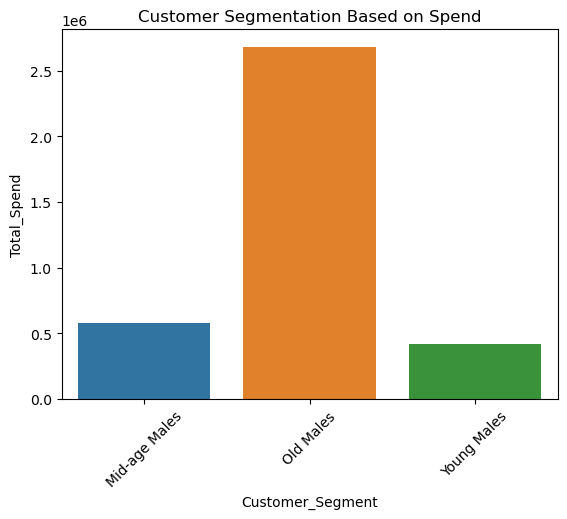

In [117]:
# Visualize the segmentation
sns.barplot(x='Customer_Segment', y='Total_Spend', data=customer_spend)
plt.title('Customer Segmentation Based on Spend')
plt.xticks(rotation=45)
plt.show()

#### **2. Calculate Spend in Terms of Product, State, and Payment Method**

Products and their total spend:
          P_CATEGORY  Total_Spend
0         APPLIANCES  216169.3255
1      BABY CLOTHING  192138.0920
2          BABY TOYS  152650.1505
3            BEDDING  229787.5980
4           CLOTHING  273957.8460
5          COMPUTERS  430589.4980
6              DECOR  453817.2665
7        ELECTRONICS  378115.5095
8              GAMES  208155.3110
9   KITCHEN & DINING  280447.1145
10           LUGGAGE  190616.6220
11   OFFICE SUPPLIES  349072.2410
12             SHOES  319900.1110


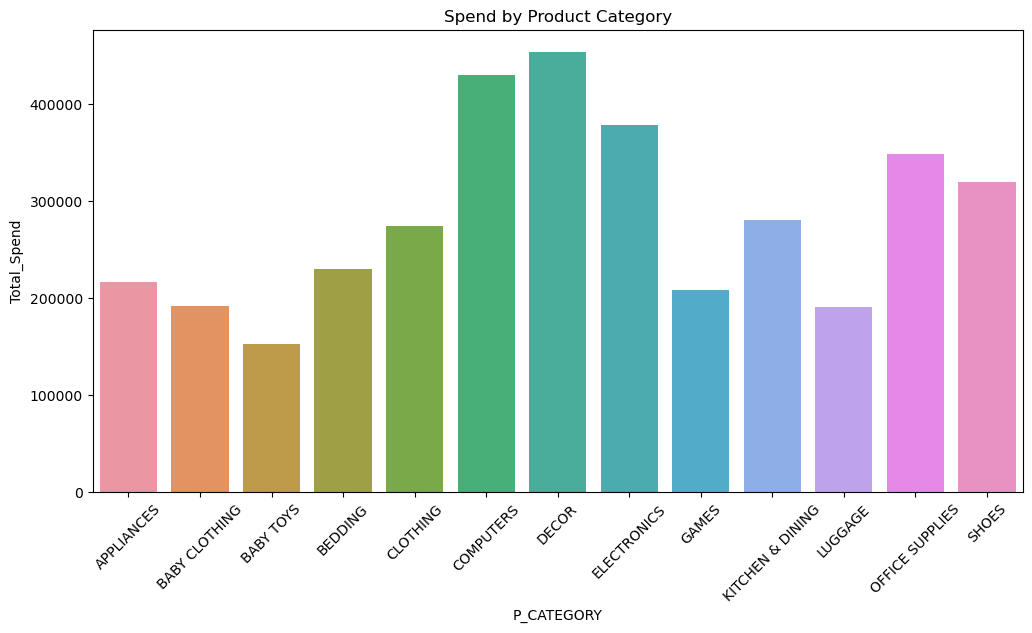

In [118]:
# Group by Product and calculate the total spend
spend_by_product = df_merged.groupby('P_CATEGORY').agg(Total_Spend=('Selling_price', 'sum')).reset_index()
print("Products and their total spend:")
print(spend_by_product)

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(x='P_CATEGORY', y='Total_Spend', data=spend_by_product)
plt.title('Spend by Product Category')
plt.xticks(rotation=45)
plt.show()

States and their total spend:
           State   Total_Spend
0        Arizona  2.267998e+05
1     California  1.045922e+06
2       Illinois  2.868160e+05
3       Kentucky  3.056217e+05
4  Massachusetts  2.476338e+05
5       Missouri  9.748600e+04
6         Nevada  2.365191e+05
7           Ohio  1.469115e+05
8          Texas  7.785739e+05
9     Washington  3.031332e+05


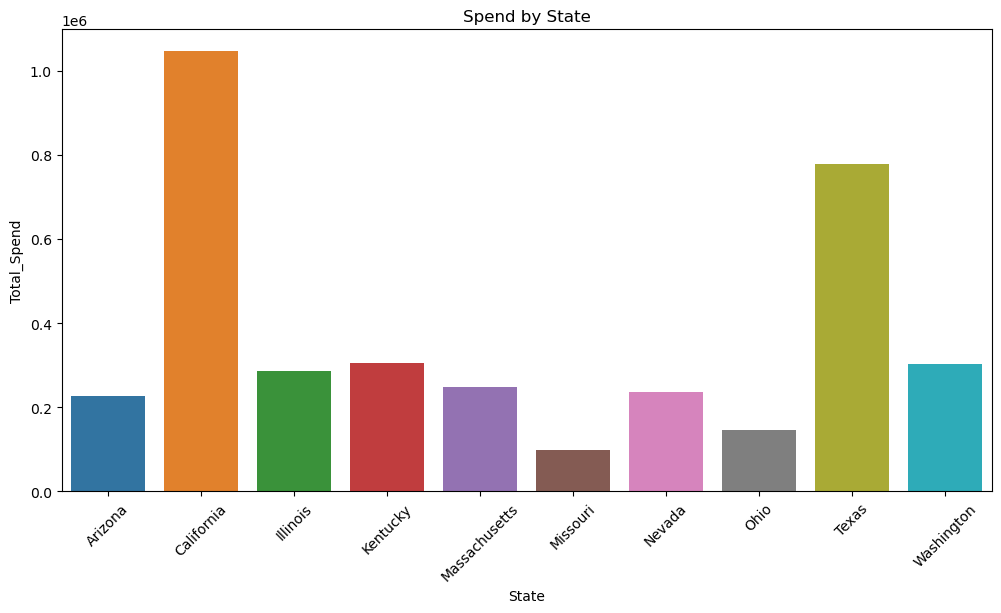

In [119]:
# Group by State and calculate the total spend
spend_by_state = df_merged.groupby('State').agg(Total_Spend=('Selling_price', 'sum')).reset_index()
print("States and their total spend:")
print(spend_by_state)

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(x='State', y='Total_Spend', data=spend_by_state)
plt.title('Spend by State')
plt.xticks(rotation=45)
plt.show()

Payment Methods and their total spend:
           Payment Method   Total_Spend
0             Credit card  1.330573e+06
1              Debit card  1.153666e+05
2          Deirect debits  2.193091e+04
3               Gift card  2.595651e+04
4  Mobile carrier Billing  1.518548e+06
5           Paypal wallet  3.194428e+04
6            Prepaid card  6.310975e+05


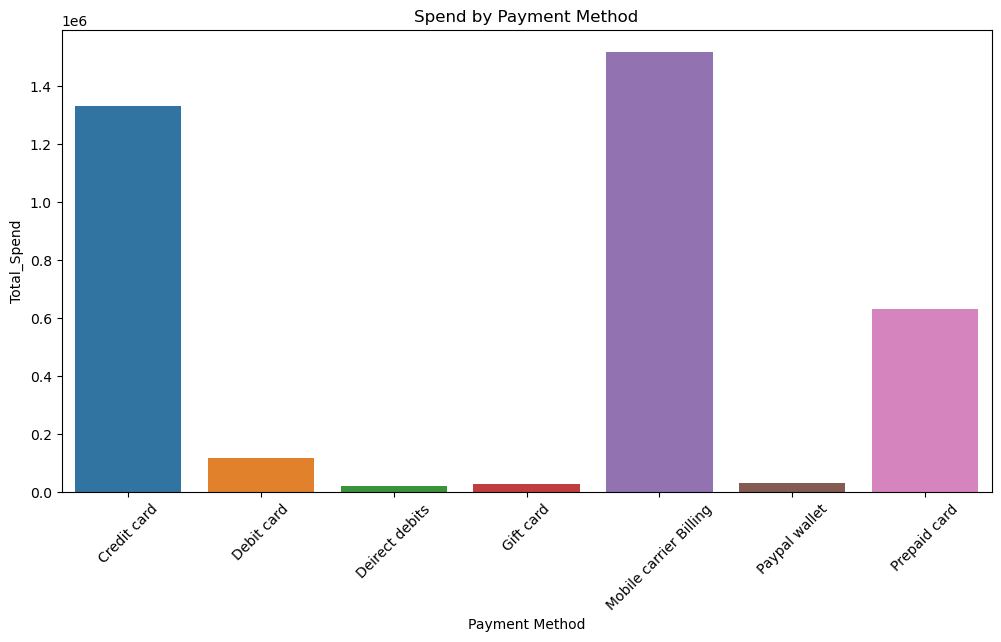

In [120]:
# Group by Payment Method and calculate the total spend
spend_by_payment = df_merged.groupby('Payment Method').agg(Total_Spend=('Selling_price', 'sum')).reset_index()
print("Payment Methods and their total spend:")
print(spend_by_payment)

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(x='Payment Method', y='Total_Spend', data=spend_by_payment)
plt.title('Spend by Payment Method')
plt.xticks(rotation=45)
plt.show()

#### **3. Highest 5 Spendings in All Categories**

In [121]:
# Find the top 5 spending for Product
top_5_product = spend_by_product.nlargest(5, 'Total_Spend')
print("Top 5 Product Categories by Spend:")
print(top_5_product)

Top 5 Product Categories by Spend:
         P_CATEGORY  Total_Spend
6             DECOR  453817.2665
5         COMPUTERS  430589.4980
7       ELECTRONICS  378115.5095
11  OFFICE SUPPLIES  349072.2410
12            SHOES  319900.1110


In [122]:
# Find the top 5 spending for State
top_5_state = spend_by_state.nlargest(5, 'Total_Spend')
print("Top 5 States by Spend:")
print(top_5_state)

Top 5 States by Spend:
        State   Total_Spend
1  California  1.045922e+06
8       Texas  7.785739e+05
3    Kentucky  3.056217e+05
9  Washington  3.031332e+05
2    Illinois  2.868160e+05


In [123]:
# Find the top 5 spending for Payment Method
top_5_payment = spend_by_payment.nlargest(5, 'Total_Spend')
print("Top 5 Payment Methods by Spend:")
print(top_5_payment)

Top 5 Payment Methods by Spend:
           Payment Method   Total_Spend
4  Mobile carrier Billing  1.518548e+06
0             Credit card  1.330573e+06
6            Prepaid card  6.310975e+05
1              Debit card  1.153666e+05
5           Paypal wallet  3.194428e+04


#### **4. Opinion on Return Category (State, Age Group, Condition, etc.)**

In [124]:
# Filter for returned items (where Return_ind is 1)
returned_items_check = df_merged[df_merged['Return_ind'] == 1]

# Check if there are returned items
if returned_items_check.shape[0] > 0:
    # Group by relevant columns and count returns
    return_analysis = returned_items_check.groupby(['State', 'Age', 'CONDTION', 'P_CATEGORY']).agg(Returns=('Transaction ID', 'count')).reset_index()

    # Display the results
    print("Return Analysis by State, Age, Condition, and Category:")
    print(return_analysis)
else:
    print("No returned items found in the dataset.")

Return Analysis by State, Age, Condition, and Category:
          State  Age     CONDTION        P_CATEGORY  Returns
0       Arizona   33          New             SHOES        1
1       Arizona   33  Refurbished           LUGGAGE        1
2       Arizona   33  Refurbished   OFFICE SUPPLIES        2
3       Arizona   41          New         COMPUTERS        2
4       Arizona   41  Refurbished  KITCHEN & DINING        1
..          ...  ...          ...               ...      ...
732  Washington   87          New         COMPUTERS        1
733  Washington   87          New             DECOR        2
734  Washington   87         Used           LUGGAGE        1
735  Washington   93          New        APPLIANCES        2
736  Washington   93         Used     BABY CLOTHING        1

[737 rows x 5 columns]


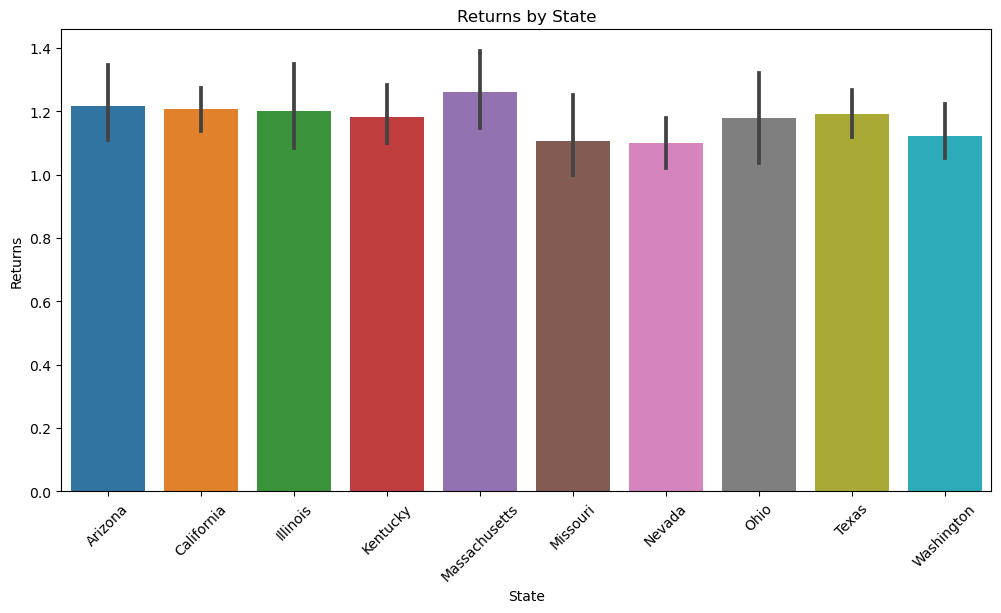

In [125]:
# Visualization of returns by state
plt.figure(figsize=(12, 6))
sns.barplot(x='State', y='Returns', data=return_analysis)
plt.title('Returns by State')
plt.xticks(rotation=45)
plt.show()

#### **5. Customer Profile in Terms of Timing of Their Order**

In [126]:
## Extract hour from the order time and create a customer profile based on time
df_merged['Order_Hour'] = pd.to_datetime(df_merged['Time'], format='%H:%M:%S').dt.hour

# Group by the hour and calculate the number of orders
order_timing = df_merged.groupby('Order_Hour').agg(Number_of_Orders=('Transaction ID', 'count')).reset_index()
print("Customer Orders by Time of Day:")
print(order_timing)

Customer Orders by Time of Day:
    Order_Hour  Number_of_Orders
0            0                57
1            1                53
2            2                50
3            3                67
4            4                46
5            5                55
6            6                44
7            7                66
8            8                66
9            9                54
10          10                55
11          11                78
12          12                68
13          13                53
14          14                61
15          15                42
16          16                54
17          17                71
18          18                63
19          19                50
20          20                58
21          21                65
22          22                63
23          23                62


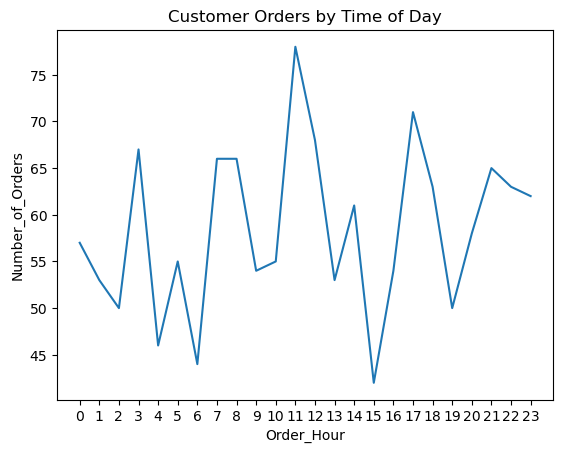

In [127]:
# Visualize order timing
sns.lineplot(x='Order_Hour', y='Number_of_Orders', data=order_timing)
plt.title('Customer Orders by Time of Day')
plt.xticks(range(0, 24))
plt.show()

#### **6. Payment Method with Most Discounts**

In [128]:
# Calculate the discount applied by comparing Price and Selling Price
df_merged['Discount_Applied'] = df_merged['Price'] - df_merged['Selling_price']

# Group by Payment Method and calculate total discount
discount_by_payment = df_merged.groupby('Payment Method').agg(Total_Discount=('Discount_Applied', 'sum')).reset_index()
print("Total Discount by Payment Method:")
print(discount_by_payment)

Total Discount by Payment Method:
           Payment Method  Total_Discount
0             Credit card      17498.2520
1              Debit card       1558.0180
2          Deirect debits        345.0000
3               Gift card        343.7325
4  Mobile carrier Billing      19315.6985
5           Paypal wallet        347.0000
6            Prepaid card       7599.5835


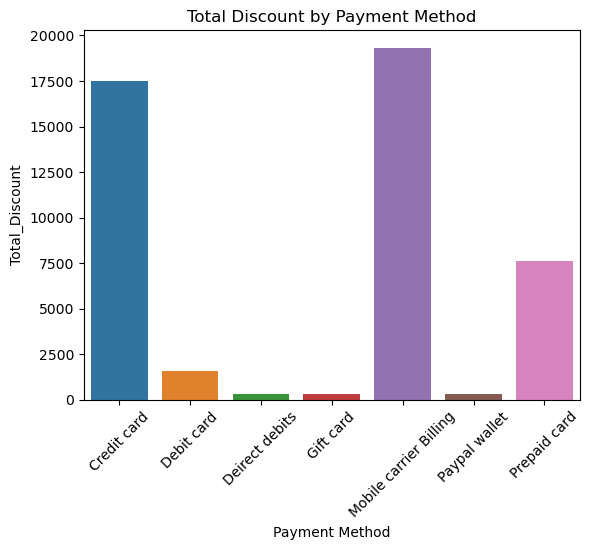

In [129]:
# Visualize
sns.barplot(x='Payment Method', y='Total_Discount', data=discount_by_payment)
plt.title('Total Discount by Payment Method')
plt.xticks(rotation=45)
plt.show()

#### **7. Profile for High vs Low Value Items (Number of Orders)**

In [130]:
# Define a threshold for high vs low value items (e.g., median price)
threshold = df_merged['Price'].median()

# Classify items as high or low value
df_merged['Value_Type'] = df_merged['Price'].apply(lambda x: 'High Value' if x > threshold else 'Low Value')

# Group by Value Type and count orders
value_profile = df_merged.groupby('Value_Type').agg(Number_of_Orders=('Transaction ID', 'count')).reset_index()
print("High vs Low Value Items - Number of Orders:")
print(value_profile)

High vs Low Value Items - Number of Orders:
   Value_Type  Number_of_Orders
0  High Value               694
1   Low Value               707


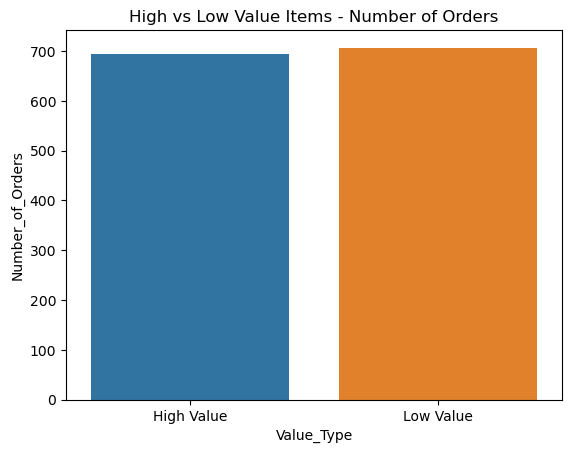

In [131]:
# Visualize
sns.barplot(x='Value_Type', y='Number_of_Orders', data=value_profile)
plt.title('High vs Low Value Items - Number of Orders')
plt.show()

#### **8. Impact of Discounts on Number of Orders**

In [132]:
# Group by Merchant and calculate total discount and total number of orders
discount_order_relation = df_merged.groupby('Merchant_name').agg(
    Total_Discount=('Discount_Applied', 'sum'),
    Number_of_Orders=('Transaction ID', 'count')
).reset_index()

print("Impact of Discount on Number of Orders:")
print(discount_order_relation)

Impact of Discount on Number of Orders:
         Merchant_name  Total_Discount  Number_of_Orders
0       Barnes & Noble       3565.5565               107
1        Cole Hardware       2677.2910                84
2               Costco       1355.7810                33
3             DFLOWERS       1750.4055                53
4             DODOcase       2643.9555                79
5        Guitar Center       3245.3035                91
6             Gymboree       2179.9225                64
7           L'Occitane       3080.0000                98
8            Nine West       1357.5885                47
9       Nob Hill Foods        618.0000                22
10    Peninsula Beauty       2440.4690                66
11            PetSmart       1618.6200                46
12                 REI       2240.3465                77
13         Right Start       2281.6455                58
14  Road Runner Sports       2194.7630                74
15             Staples       1813.8265          

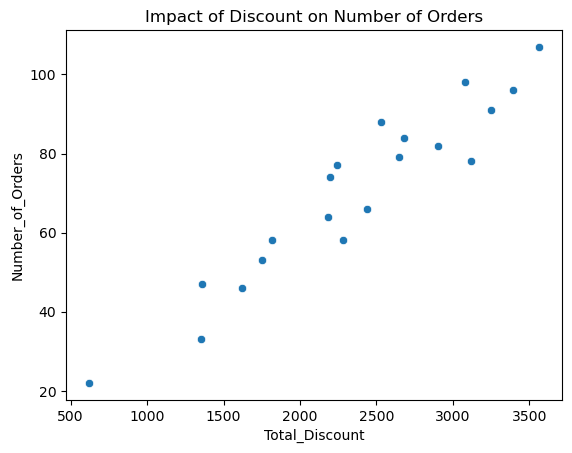

In [133]:
# Visualize the relationship between discount and number of orders
sns.scatterplot(x='Total_Discount', y='Number_of_Orders', data=discount_order_relation)
plt.title('Impact of Discount on Number of Orders')
plt.show()